# Sensor Data Exploration & Model Training

This notebook trains a machine learning model to classify structural health based on sensor data.

## Dataset:
- **Source**: Building Health Monitoring Dataset
- **Samples**: 1,000 real sensor readings

## Features:
- Accelerometer readings (X, Y, Z) in m/s²
- Strain gauge readings (με)
- Temperature (°C)

## Target Labels:
- 0: Healthy
- 1: Minor Damage
- 2: Severe Damage

In [1]:
# Install required packages
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Load and Explore Data

In [3]:
DATA_PATH = '../data/sensor/building_health_monitoring_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset with {len(df)} samples")

# Rename columns to match expected format
df = df.rename(columns={
    'Accel_X (m/s^2)': 'accel_x',
    'Accel_Y (m/s^2)': 'accel_y',
    'Accel_Z (m/s^2)': 'accel_z',
    'Strain (με)': 'strain',
    'Temp (°C)': 'temperature',
    'Condition Label': 'label'
})

# Drop timestamp column (not needed for classification)
if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

# Handle missing values
missing_before = df.isnull().sum().sum()
df = df.dropna()
print(f"Dropped {missing_before} missing values, {len(df)} samples remaining")

Loaded dataset with 1000 samples
Dropped 100 missing values, 904 samples remaining


In [4]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (904, 6)


,accel_x,accel_y,accel_z,strain,temperature,label
0,0.149014,0.419807,9.742482,61.843849,23.704760,0
1,-0.041479,0.277390,9.795548,82.792300,24.953195,0
2,0.194307,0.017889,9.730758,91.727889,25.027025,0
3,0.456909,-0.194081,9.779204,137.753753,25.708946,0
4,-0.070246,0.209467,9.620639,111.131062,22.949712,0


Class Distribution:
label
Healthy          637
Minor Damage     165
Severe Damage    102
Name: count, dtype: int64


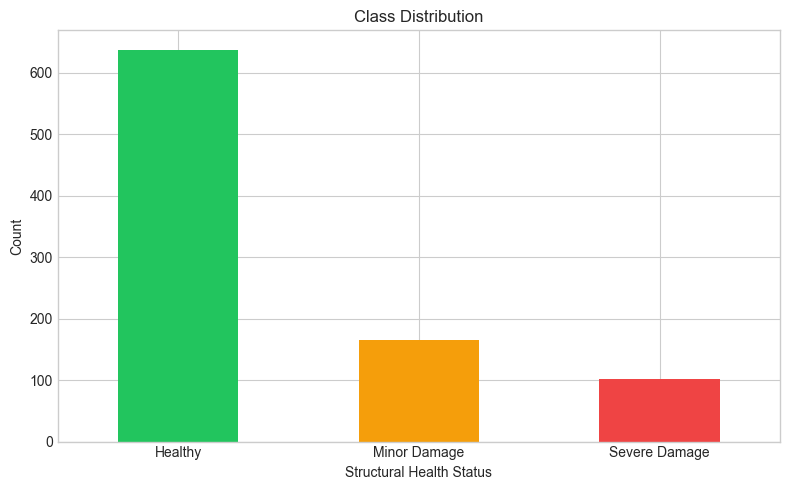

In [5]:
label_names = {0: 'Healthy', 1: 'Minor Damage', 2: 'Severe Damage'}
print("Class Distribution:")
print(df['label'].value_counts().rename(label_names))

plt.figure(figsize=(8, 5))
df['label'].map(label_names).value_counts().plot(kind='bar', color=['#22c55e', '#f59e0b', '#ef4444'])
plt.title('Class Distribution')
plt.xlabel('Structural Health Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing & Training

In [6]:
features = ['accel_x', 'accel_y', 'accel_z', 'strain', 'temperature']
X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Training: 723, Test: 181


In [7]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)
print(f"CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Training Random Forest...
CV Score: 0.797 (+/- 0.017)


In [8]:
y_pred = rf_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Minor Damage', 'Severe Damage']))

Accuracy: 0.7956

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.83      0.97      0.89       128
 Minor Damage       0.43      0.18      0.26        33
Severe Damage       0.82      0.70      0.76        20

     accuracy                           0.80       181
    macro avg       0.69      0.62      0.63       181
 weighted avg       0.75      0.80      0.76       181



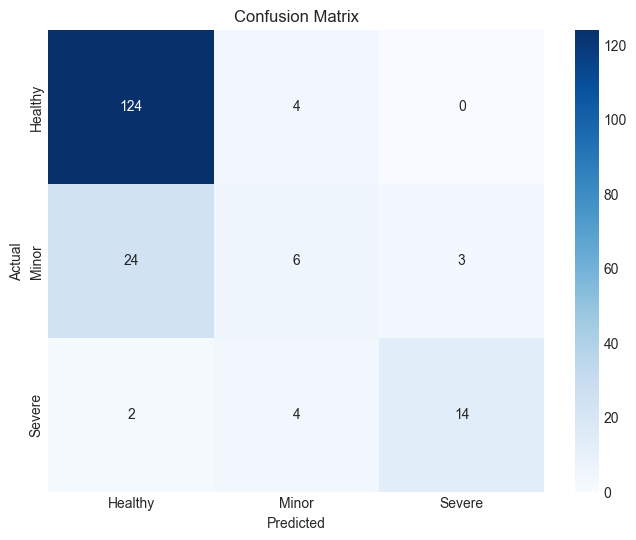

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Minor', 'Severe'],
            yticklabels=['Healthy', 'Minor', 'Severe'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 3. Save Model

In [10]:
MODEL_DIR = '../backend/saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(rf_model, os.path.join(MODEL_DIR, 'sensor_classifier.pkl'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'sensor_scaler.pkl'))

print(f"Model saved to {MODEL_DIR}/sensor_classifier.pkl")
print(f"Scaler saved to {MODEL_DIR}/sensor_scaler.pkl")

Model saved to ../backend/saved_models/sensor_classifier.pkl
Scaler saved to ../backend/saved_models/sensor_scaler.pkl


In [11]:
# Test prediction
test_sample = np.array([[0.02, 0.01, -9.81, 120, 24]])
test_scaled = scaler.transform(test_sample)
prediction = rf_model.predict(test_scaled)
probabilities = rf_model.predict_proba(test_scaled)

print(f"Test sample: {test_sample[0]}")
print(f"Prediction: {label_names[prediction[0]]}")
print(f"Confidence: {max(probabilities[0]):.2%}")

Test sample: [ 2.00e-02  1.00e-02 -9.81e+00  1.20e+02  2.40e+01]
Prediction: Healthy
Confidence: 56.00%


c:\Users\dipen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
